<a href="https://colab.research.google.com/github/Kartik-Chhonkar/Next-Day-Pollution-Predictor/blob/main/logisticReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler,QuantileTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df=pd.read_csv('City_Types.csv')
df.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,Type
0,2024-01-01 00:00:00+00:00,Moscow,208.0,15.9,13.2,44.0,8.6,9.4,Industrial
1,2024-01-01 01:00:00+00:00,Moscow,207.0,17.4,13.7,44.0,8.6,10.5,Industrial
2,2024-01-01 02:00:00+00:00,Moscow,217.0,19.0,15.5,43.0,10.4,12.9,Industrial
3,2024-01-01 03:00:00+00:00,Moscow,231.0,21.0,20.7,36.0,12.3,15.3,Industrial
4,2024-01-01 04:00:00+00:00,Moscow,263.0,34.5,27.2,27.0,13.6,20.0,Industrial


In [ ]:
df.shape

(52704, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  object 
 1   City    52704 non-null  object 
 2   CO      52704 non-null  float64
 3   NO2     52704 non-null  float64
 4   SO2     52704 non-null  float64
 5   O3      52704 non-null  float64
 6   PM2.5   52704 non-null  float64
 7   PM10    52704 non-null  float64
 8   Type    52704 non-null  object 
dtypes: float64(6), object(3)
memory usage: 3.6+ MB


In [ ]:
df['City'].unique()

array(['Moscow', 'Delhi', 'Beijing', 'Zurich', 'Vancouver', 'Stockholm'],
      dtype=object)

In [ ]:
df['CO'].value_counts()

,count
CO,
171.0,309
177.0,302
173.0,301
174.0,293
178.0,284
...,...
4788.0,1
5515.0,1
4785.0,1


In [ ]:
df['NO2'].value_counts()

,count
NO2,
6.2,186
6.0,184
5.2,184
4.8,182
5.9,176
...,...
141.0,1
128.6,1
125.4,1


In [ ]:
df['SO2'].value_counts()

,count
SO2,
0.3,2914
0.2,2656
0.4,2610
0.5,2101
0.6,1578
...,...
220.2,1
251.1,1
353.5,1


In [ ]:
df['O3'].value_counts()

,count
O3,
0.0,2338
1.0,857
56.0,716
57.0,693
58.0,688
...,...
342.0,1
310.0,1
334.0,1


In [ ]:
df['PM2.5'].value_counts()

,count
PM2.5,
3.2,344
3.6,339
3.7,323
3.5,318
4.0,317
...,...
93.7,1
68.3,1
86.9,1


In [ ]:
df['PM10'].value_counts()

,count
PM10,
7.5,265
8.1,258
6.9,248
7.9,244
6.8,242
...,...
441.4,1
462.9,1
475.0,1


In [ ]:
df['Type'].value_counts()

,count
Type,
Industrial,26352
Residential,26352


In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,Type
0,2024-01-01 00:00:00+00:00,Moscow,208.0,15.9,13.2,44.0,8.6,9.4,Industrial
1,2024-01-01 01:00:00+00:00,Moscow,207.0,17.4,13.7,44.0,8.6,10.5,Industrial
2,2024-01-01 02:00:00+00:00,Moscow,217.0,19.0,15.5,43.0,10.4,12.9,Industrial
3,2024-01-01 03:00:00+00:00,Moscow,231.0,21.0,20.7,36.0,12.3,15.3,Industrial
4,2024-01-01 04:00:00+00:00,Moscow,263.0,34.5,27.2,27.0,13.6,20.0,Industrial


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Date    52704 non-null  datetime64[ns, UTC]
 1   City    52704 non-null  object             
 2   CO      52704 non-null  float64            
 3   NO2     52704 non-null  float64            
 4   SO2     52704 non-null  float64            
 5   O3      52704 non-null  float64            
 6   PM2.5   52704 non-null  float64            
 7   PM10    52704 non-null  float64            
 8   Type    52704 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(6), object(2)
memory usage: 3.6+ MB


In [ ]:
df['Month']=df['Date'].dt.month

In [ ]:
df['Year']=df['Date'].dt.year

In [ ]:
df['Day']=df['Date'].dt.day

In [ ]:
df.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,Type,Month,Year,Day
0,2024-01-01 00:00:00+00:00,Moscow,208.0,15.9,13.2,44.0,8.6,9.4,Industrial,1,2024,1
1,2024-01-01 01:00:00+00:00,Moscow,207.0,17.4,13.7,44.0,8.6,10.5,Industrial,1,2024,1
2,2024-01-01 02:00:00+00:00,Moscow,217.0,19.0,15.5,43.0,10.4,12.9,Industrial,1,2024,1
3,2024-01-01 03:00:00+00:00,Moscow,231.0,21.0,20.7,36.0,12.3,15.3,Industrial,1,2024,1
4,2024-01-01 04:00:00+00:00,Moscow,263.0,34.5,27.2,27.0,13.6,20.0,Industrial,1,2024,1


In [ ]:
df['Day'].value_counts()

,count
Day,
1,1728
2,1728
3,1728
4,1728
5,1728
6,1728
7,1728
8,1728
9,1728


In [ ]:
df.drop('Date',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    52704 non-null  object 
 1   CO      52704 non-null  float64
 2   NO2     52704 non-null  float64
 3   SO2     52704 non-null  float64
 4   O3      52704 non-null  float64
 5   PM2.5   52704 non-null  float64
 6   PM10    52704 non-null  float64
 7   Type    52704 non-null  object 
 8   Month   52704 non-null  int32  
 9   Year    52704 non-null  int32  
 10  Day     52704 non-null  int32  
dtypes: float64(6), int32(3), object(2)
memory usage: 3.8+ MB


In [ ]:
num_features=[feature for feature in df.columns if df[feature].dtypes!='O']
cat_features=[feature for feature in df.columns if df[feature].dtypes=='O' and feature!='Type']

In [ ]:
print(num_features)

['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'Month', 'Day']


In [ ]:
print(cat_features)

['City']


In [ ]:
df[num_features].corr()

,CO,NO2,SO2,O3,PM2.5,PM10,Month,Year,Day
CO,1.000000,0.555477,0.806088,-0.244973,0.857725,0.726941,0.077096,NaN,0.002540
NO2,0.555477,1.000000,0.624323,-0.462074,0.649295,0.557913,0.023410,NaN,0.009507
SO2,0.806088,0.624323,1.000000,-0.260594,0.857254,0.724543,0.011199,NaN,-0.006963
O3,-0.244973,-0.462074,-0.260594,1.000000,-0.151040,-0.010099,-0.059798,NaN,0.011860
PM2.5,0.857725,0.649295,0.857254,-0.151040,1.000000,0.901894,0.032692,NaN,0.007132
PM10,0.726941,0.557913,0.724543,-0.010099,0.901894,1.000000,-0.039833,NaN,-0.009591
Month,0.077096,0.023410,0.011199,-0.059798,0.032692,-0.039833,1.000000,NaN,0.006443
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,0.002540,0.009507,-0.006963,0.011860,0.007132,-0.009591,0.006443,NaN,1.000000


In [ ]:
df['Year'].value_counts()

,count
Year,
2024,52704


In [ ]:
df.drop('Year',axis=1,inplace=True)

In [ ]:
num_features.remove('Year')

In [ ]:
print(num_features)

['CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'Month', 'Day']


In [ ]:
print(cat_features)

['City', 'Type']


In [ ]:
df[num_features].corr()

,CO,NO2,SO2,O3,PM2.5,PM10,Month,Day
CO,1.000000,0.555477,0.806088,-0.244973,0.857725,0.726941,0.077096,0.002540
NO2,0.555477,1.000000,0.624323,-0.462074,0.649295,0.557913,0.023410,0.009507
SO2,0.806088,0.624323,1.000000,-0.260594,0.857254,0.724543,0.011199,-0.006963
O3,-0.244973,-0.462074,-0.260594,1.000000,-0.151040,-0.010099,-0.059798,0.011860
PM2.5,0.857725,0.649295,0.857254,-0.151040,1.000000,0.901894,0.032692,0.007132
PM10,0.726941,0.557913,0.724543,-0.010099,0.901894,1.000000,-0.039833,-0.009591
Month,0.077096,0.023410,0.011199,-0.059798,0.032692,-0.039833,1.000000,0.006443
Day,0.002540,0.009507,-0.006963,0.011860,0.007132,-0.009591,0.006443,1.000000


<Axes: >

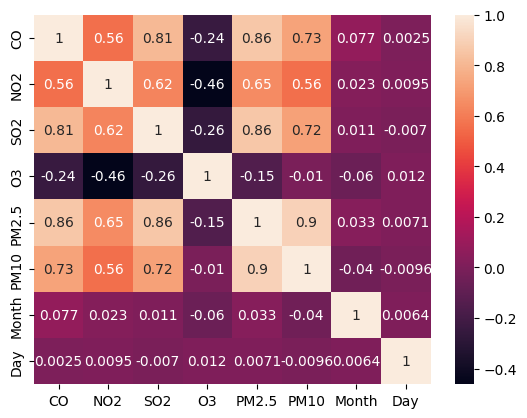

In [ ]:
sns.heatmap(df[num_features].corr(),annot=True)

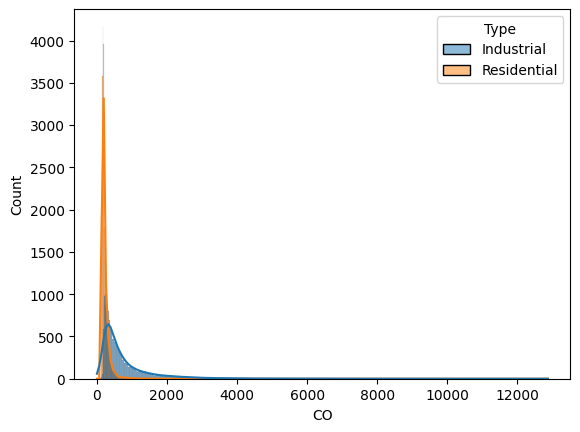

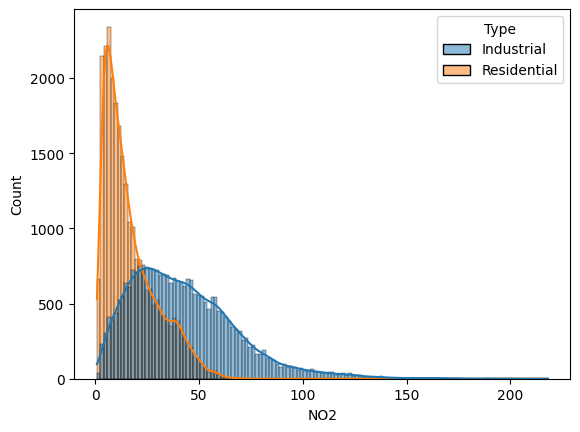

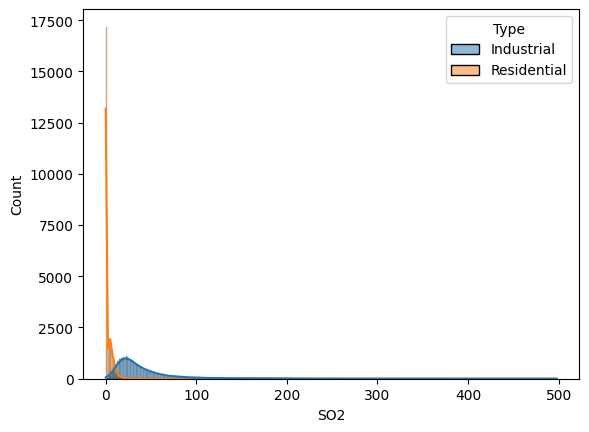

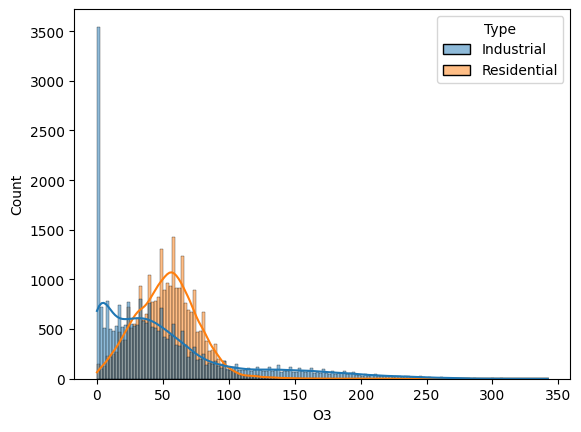

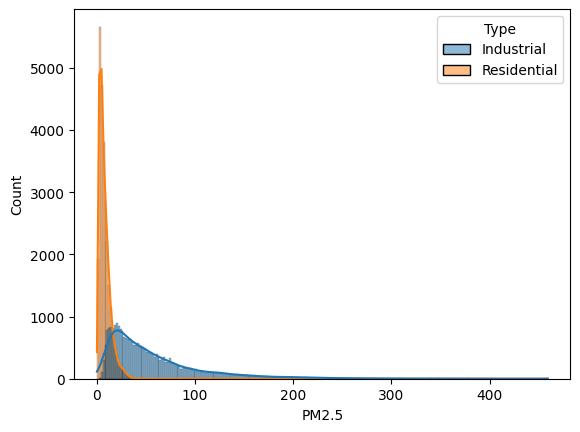

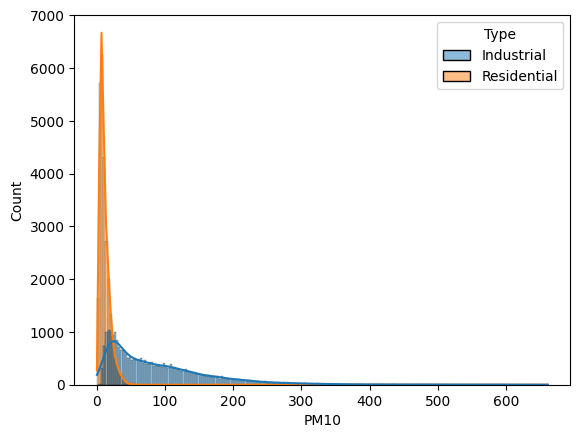

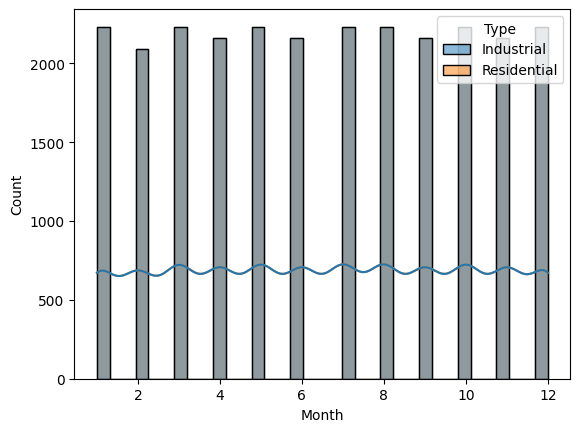

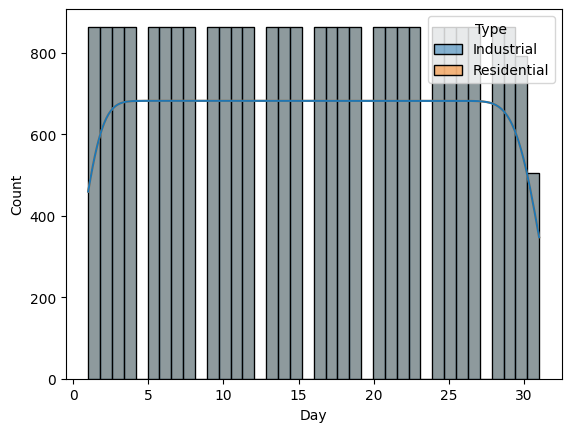

In [ ]:
for i in num_features:
    sns.histplot(x=i,data=df,hue='Type',kde=True)
    plt.show()

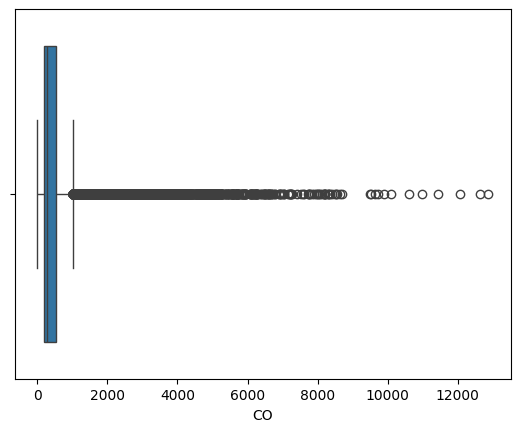

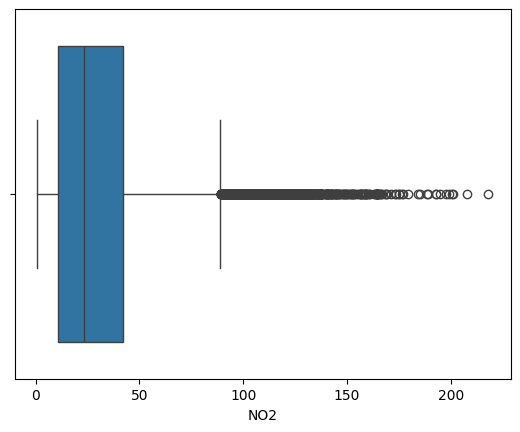

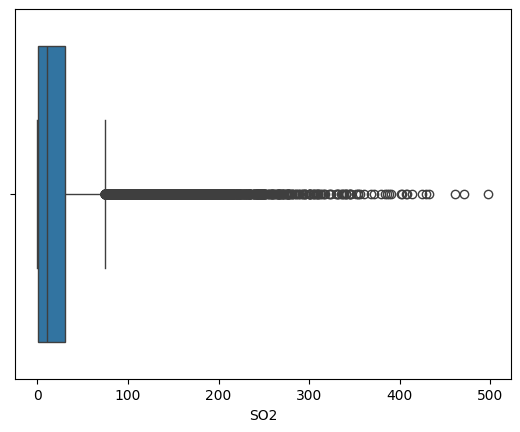

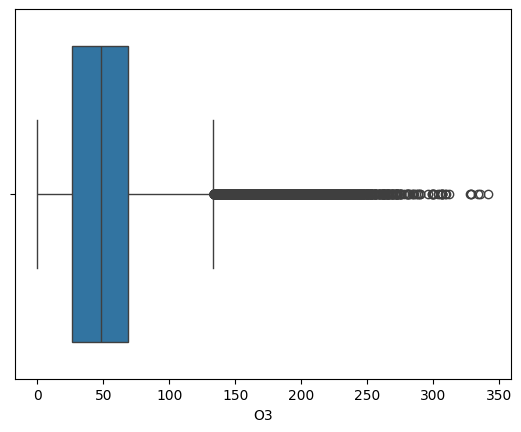

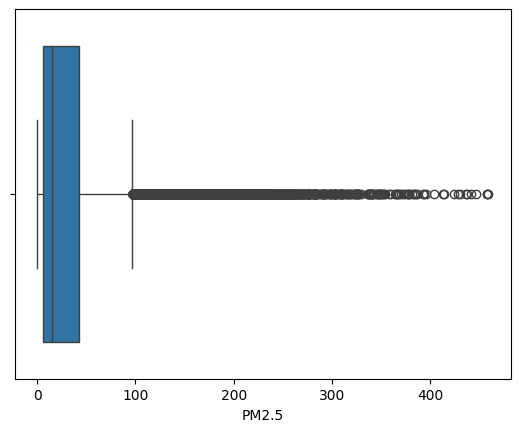

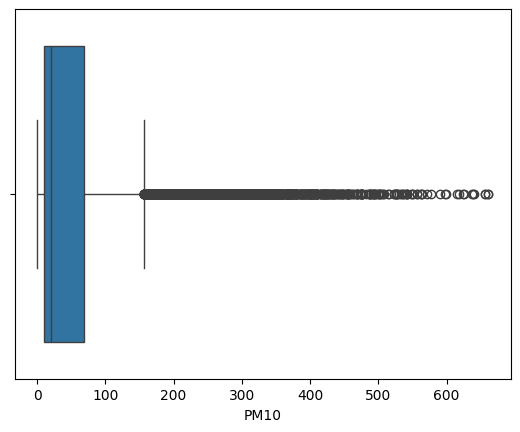

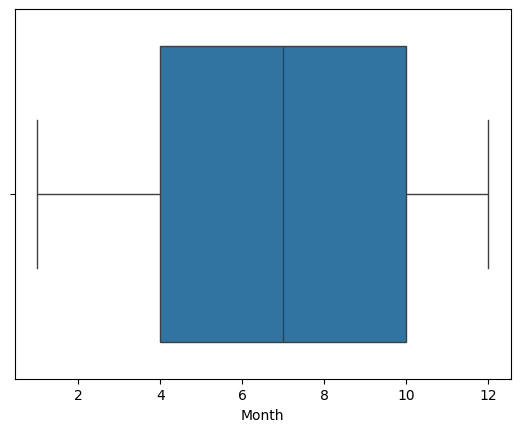

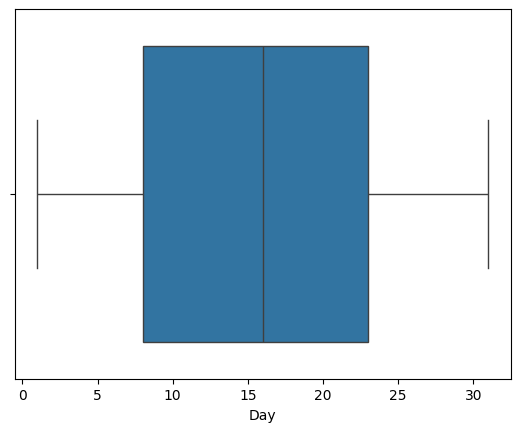

In [ ]:
for i in num_features:
    sns.boxplot(x=i,data=df)
    plt.show()

In [ ]:
le=LabelEncoder()
df['City']=le.fit_transform(df['City'])

In [ ]:
X=df.drop('Type',axis=1)
y=df[['Type']]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
qt=QuantileTransformer(output_distribution='normal')
scaler=StandardScaler()
ct=ColumnTransformer(
    [('qt',qt,num_features),
     ('scaler',scaler,num_features)]
)

In [ ]:
X_train_ct=ct.fit_transform(X_train)
X_test=ct.transform(X_test)

In [ ]:
lr=LogisticRegression()
lr.fit(X_train_ct,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
y_pred=lr.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9773589678725019


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Industrial       0.98      0.98      0.98      7885
 Residential       0.98      0.98      0.98      7927

    accuracy                           0.98     15812
   macro avg       0.98      0.98      0.98     15812
weighted avg       0.98      0.98      0.98     15812



In [ ]:
confusion_matrix(y_test,y_pred)

array([[7689,  196],
       [ 162, 7765]])